In [1]:
import sys
import os

# Agregar el directorio padre al sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import os
from sklearn.preprocessing import StandardScaler
import sqlite3

import json

import mlp.promok_functions as pk
import mlp.promok_models_config as pkconfig
from mlp.dataframe_tracker import *

import cashia_core.data_channel.promok_datapipe_func as pkdp
import cashia_core.data_channel.pm_datapipeline as pmdp


from datetime import datetime

In [2]:
import sys, pandas as pd, numpy as np, sklearn
print(sys.executable)
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("sklearn", sklearn.__version__)

c:\Users\juan_\.conda\envs\cashia_env\python.exe
pandas 1.5.3
numpy 1.26.0
sklearn 1.2.2


In [3]:
date_and_time = datetime.now()
# Convierte la fecha y hora en una cadena con el formato deseado
str_date_and_time = date_and_time.strftime("%Y:%m:%d:%H:%M")

print(str_date_and_time)

all_stats = pk.ModelsStats()
all_stats.base_stats

2026:06:12:18:21


dict_values(['12/06/2026 18:21:26', 'Undefined', 'Undefined', 'Undefined', 'Undefined', 'Unknown', 'Unknown', -1, -1, -1, -1.0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, None, -1, 'Unknown', 'Unknown', 'None', 'None', 'None'])

## 1 Lectura de datos de configuración

### 1.1 Datos categóricos

In [4]:
print('Configuration file: ', pkconfig.configuration_file_name)
all_features = pd.read_excel("./config/"+pkconfig.configuration_file_name, index_col=0)
features = all_features[all_features[pkconfig.conf_column] == 'Sí']

features_to_use = set(features['Característica'].values)
features_to_use

Configuration file:  CashIA_ConfFile.xlsx


c:\Users\juan_\.conda\envs\cashia_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


{'Ciclo',
 'Deficit',
 'Dependientes',
 'Edad Solicitud',
 'Egresos',
 'Frecuencia_Ant',
 'Genero',
 'Incobrable',
 'IngresoPercapita',
 'Ingresos',
 'Mes inicial',
 'Monto',
 'Monto_Ant',
 'Odds',
 'Score CC',
 'Score_Ant'}

In [5]:
categorical_features = set(features[(features['Tipo de dato'] == 'Categórico') & (features['Tipo de variable'] == 'Predictor')]['Característica'].values)
categorical_features

{'Genero'}

### 1.2 Datos cuantitativos

In [6]:
quantitative_features = set(features[(features['Tipo de dato'] == 'Cuantitativo') & (features['Tipo de variable'] == 'Predictor')]['Característica'].values)
quantitative_features

{'Ciclo',
 'Deficit',
 'Dependientes',
 'Edad Solicitud',
 'Egresos',
 'Frecuencia_Ant',
 'IngresoPercapita',
 'Ingresos',
 'Mes inicial',
 'Monto',
 'Monto_Ant',
 'Odds',
 'Score CC',
 'Score_Ant'}

In [7]:
monetary_features = features[features['Monetario'] == 1]['Característica']

### 1.3 Registro de las características de los datos en las estadísticas

In [8]:
categorical_list = list(categorical_features)
categorical_list.sort()

quantitative_list = list(quantitative_features)
quantitative_list.sort()

all_stats.base_stats.fields["Model"] = pkconfig.conf_column
all_stats.base_stats.fields["Features"] = json.dumps({"Categorical":categorical_list,"Quantitative":quantitative_list})
all_stats.base_stats.fields["Notes"] = pkconfig.notes
all_stats.base_stats.fields["SourceFile"] = pkconfig.data_file_name

In [9]:
all_stats.base_stats

dict_values(['12/06/2026 18:21:26', 'Undefined', 'Undefined', 'Undefined', 'Undefined', 'Unknown', 'Unknown', -1, -1, -1, -1.0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, None, -1, '{"Categorical": ["Genero"], "Quantitative": ["Ciclo", "Deficit", "Dependientes", "Edad Solicitud", "Egresos", "Frecuencia_Ant", "IngresoPercapita", "Ingresos", "Mes inicial", "Monto", "Monto_Ant", "Odds", "Score CC", "Score_Ant"]}', 'Unknown', "zip_digits = 4  Usando: standardizationSin remplazar campos vacios por 'Unknown'", 'Data Set Cashia EntrenamientoRNV_CC_CSProcessed.csv', 'RNV_CC_CS'])

## 2 Lectura de los datos de entrenamiento

In [10]:
print('Data file: ', pkconfig.data_file_name)
data = pd.read_csv("./data/"+pkconfig.data_file_name, parse_dates=['Fecha Inicial'], index_col=0, dayfirst=True)
# Convertir a entero el índice
data.index = data.index.astype(int)
# Ordenar el DataFrame por el índice de menor a mayor
data = data.sort_index()
# pkdp.print_sizes(data)
data_tracker = DataFrameEvolutionTracker(data)
data_tracker.to_dataframe()

Data file:  Data Set Cashia EntrenamientoRNV_CC_CSProcessed.csv


,Step,Rows,Columns,Column Names
0,Initialization,1589,17,"[Fecha Inicial, Monto, Edad Solicitud, Genero,..."


### 2.1 Borramos la columna de 'Score' si está presente ya que es una variable 'Target' usada en otro contexto.

In [11]:
if 'Score' in data.columns:
    data = data.drop(columns=['Score'])

In [12]:
data.head()

,Fecha Inicial,Monto,Edad Solicitud,Genero,Dependientes,Ingresos,Egresos,Score CC,Ciclo,Monto_Ant,Frecuencia_Ant,Incobrable,Score_Ant,Deficit,IngresoPercapita,Odds,Mes inicial
id_solicitud,,,,,,,,,,,,,,,,,
67811,2023-01-11,5000,29,Femenino,1,8000,4000,662,3,5000,1.134702,0,0.0,4000,4000.0,6.1,1
69057,2023-01-20,3000,25,Femenino,1,8500,3000,667,4,4000,1.001207,0,0.0,5500,4250.0,8.3,1
69202,2023-01-21,7000,56,Masculino,0,14000,8000,420,3,7000,1.063777,1,0.0,6000,14000.0,1.2,1
69309,2023-01-23,6000,42,Femenino,3,7200,4000,552,2,5000,1.001208,1,0.0,3200,1800.0,2.9,1
69733,2023-01-24,6000,47,Femenino,0,6000,0,436,3,5000,0.945585,1,0.0,6000,6000.0,1.3,1


### 2.2 solo tomamos los datos hasta la fecha indicada

In [13]:
print(data.shape)
data = data[(data['Fecha Inicial'] <= pkconfig.max_date) & (data['Fecha Inicial'] >= pkconfig.min_date)]
pkdp.print_sizes(data)
data_tracker.register_step("Filtered by date range", data)
data_tracker.to_dataframe()

(1589, 17)
Rows: 1589
Columns: 17
Max index: 222983


,Step,Rows,Columns,Column Names
0,Initialization,1589,17,"[Fecha Inicial, Monto, Edad Solicitud, Genero,..."
1,Filtered by date range,1589,17,"[Fecha Inicial, Monto, Edad Solicitud, Genero,..."


### 2.3 Registramos datos para las estadísticas

In [14]:
all_stats.base_stats.fields["Size"] = len(data)

## 4 Simplificación del CP a n cifras

In [15]:
if pkconfig.zip_digits <= 4:
    print("Simplificando CP")
    if 'CP' in features_to_use:
        # Guardamos el conjunto de CP para almacenarlos posteriormente en 
        # el campo data_parameters de un modelo
        training_cps = data[['CP']]
        training_cps = training_cps.drop_duplicates().reset_index(drop=True)
        
        pkdp.transform_CP(data,'CP', pkconfig.zip_digits)
        
    if 'CP Aval' in features_to_use:
        # Guardamos el conjunto de CP Aval para almacenarlos posteriormente en 
        # el campo data_parameters de un modelo
        training_cps_aval = data[['CP Aval']]
        training_cps_aval = training_cps_aval.drop_duplicates().reset_index(drop=True)
        training_cps_aval = training_cps_aval.rename(columns={'CP Aval':'CP'})
        
        pkdp.transform_CP(data,'CP Aval', pkconfig.zip_digits)

Simplificando CP


In [16]:
data[monetary_features].head()

,Monto,Ingresos,Egresos,Monto_Ant,IngresoPercapita
id_solicitud,,,,,
67811,5000,8000,4000,5000,4000.0
69057,3000,8500,3000,4000,4250.0
69202,7000,14000,8000,7000,14000.0
69309,6000,7200,4000,5000,1800.0
69733,6000,6000,0,5000,6000.0


In [17]:
converter = pmdp.CurrentValueConverter(pkconfig.get_mlp_resource_key("inflation_table"))

In [18]:
for feature in monetary_features:
    data = converter.to_current_value(data, 'Fecha Inicial', feature)

In [19]:
data[monetary_features].head()

,Monto,Ingresos,Egresos,Monto_Ant,IngresoPercapita
id_solicitud,,,,,
67811,5714,9142,4571,5714,4571
69057,3428,9714,3428,4571,4857
69202,8000,16000,9142,8000,16000
69309,6857,8228,4571,5714,2057
69733,6857,6857,0,5714,6857


In [20]:
#data.to_excel("ProcessedData2.xlsx")

In [21]:
converter_500 = pmdp.MultipleAdjuster(500)
data = converter_500.adjust_amount(data, 'Monto')

In [22]:
data[monetary_features].head()

,Monto,Ingresos,Egresos,Monto_Ant,IngresoPercapita
id_solicitud,,,,,
67811,6000,9142,4571,5714,4571
69057,3500,9714,3428,4571,4857
69202,8000,16000,9142,8000,16000
69309,7000,8228,4571,5714,2057
69733,7000,6857,0,5714,6857


In [23]:
# Monto promedio de los "buenos pagadores"
good_payer = data[data['Incobrable']==0]
good_payer['Monto'].mean()

8034.240150093809

In [24]:
# Monto promedio de los "malos pagadores"
bad_payer = good_payer = data[data['Incobrable']==1]
bad_payer['Monto'].mean()

7775.334608030593

In [25]:
# Promedio de "Incobrabilidad"
data['Incobrable'].mean()

0.329137822529893

In [26]:
# Promedio del monto de préstamo
data['Monto'].mean()

7949.0245437382

## 3 Feature engineering directly with sklearn

In [27]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

predictors = data.drop(columns=['Incobrable', 'Fecha Inicial'])

target = data['Incobrable']

preprocessor = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=99999999),
        list(categorical_features),
    ),
    (StandardScaler(), list(quantitative_features)),
)


## 6 Run models

In [28]:
train_type = pk.BY_SIZE

In [29]:
if train_type == pk.BY_SIZE:

    
    totals = data["Incobrable"].value_counts()
    
    train_init_date = data.iloc[0]['Fecha Inicial']
    train_end_date = data.iloc[-1]['Fecha Inicial']
    
    data = data.drop('Fecha Inicial', axis=1)
    
    all_stats.base_stats.fields['Paid'] = int(totals[0])
    all_stats.base_stats.fields['Unpaid'] = int(totals[1])
    all_stats.base_stats.fields['AccMin'] = float(max(totals[0],totals[1])/(totals[0]+totals[1])*100)
    
    all_stats.base_stats.fields["TestSize"] = pkconfig.test_size
    models_tester = pk.ModelsTester(data, pkconfig.models_to_test, 
                                    pkconfig.test_size, split=pk.BY_SIZE)
    
elif train_type == pk.BY_INDEX:
    dates = data[['Fecha Inicial']]
    data = data.drop('Fecha Inicial', axis=1)
    
    data_size = data.shape[0]
    train_size = int(data_size/2)
    test_init = int(data_size*4/5)
    test_size = int(data_size/5)

    print("Data size: ", data_size)
    print("Train size: ", train_size)
    print("Test init: ", test_init)
    print("Test size: ", test_size)

    test_data = data.iloc[test_init:test_init+test_size]

    train_init_date = dates.loc[data.index[0],'Fecha Inicial']
    train_end_date = dates.loc[data.index[train_size],'Fecha Inicial']
    test_init_date = dates.loc[data.index[test_init],'Fecha Inicial']
    test_end_date = dates.loc[data.index[test_init+test_size-1],'Fecha Inicial']

    print("Evalueating with:")
    print(f"Train from: {train_init_date} to {train_end_date}")
    print(f"Test from: {test_init_date} to {test_end_date}")

    all_stats.base_stats.fields["TrainInitDate"] = str(train_init_date)
    all_stats.base_stats.fields["TrainEndDate"] = str(train_end_date)
    all_stats.base_stats.fields["TestInitDate"] = str(test_init_date)
    all_stats.base_stats.fields["TestEndDate" ] = str(test_end_date)

    all_stats.base_stats.fields["Size"] = len(test_data)

    totals = test_data["Incobrable"].value_counts()
    all_stats.base_stats.fields['Paid'] = int(totals[0])
    all_stats.base_stats.fields['Unpaid'] = int(totals[1])

    all_stats.base_stats.fields['AccMin'] = float(max(totals[0],totals[1])/(totals[0]+totals[1])*100)
    
    models_tester = pk.ModelsTester(data, pkconfig.models_to_test, pkconfig.test_size,
                                    train_init=0, train_size=train_size, test_init=test_init, 
                                    test_size=test_size, split=pk.BY_INDEX)
    all_stats.base_stats.fields["TestSize"] =  models_tester.x_test.shape[0]/models_tester.data.shape[0]
else:
    train_init_date = data.iloc[0]['Fecha Inicial']
    train_end_date = pd.to_datetime('2022-12-22')

    test_init_date = train_end_date + pd.Timedelta(days=1)
    test_end_date = pd.to_datetime('2023-03-22')
    
    print("Evalueating with:")
    print(f"Train from: {train_init_date} to {train_end_date}")
    print(f"Test from: {test_init_date} to {test_end_date}")
    
  
    all_stats.base_stats.fields["TrainInitDate"] = str(train_init_date)
    all_stats.base_stats.fields["TrainEndDate"] = str(train_end_date)
    all_stats.base_stats.fields["TestInitDate"] = str(test_init_date)
    all_stats.base_stats.fields["TestEndDate" ] = str(test_end_date)

    
    models_tester = pk.ModelsTester(data, pkconfig.models_to_test,  
                                    train_end_date=train_end_date,
                                    test_end_date=test_end_date,
                                    split=pk.BY_DATE)
    
    all_stats.base_stats.fields["TestSize"] = models_tester.x_test.shape[0]/models_tester.data.shape[0]
    all_stats.base_stats.fields["Size"] = models_tester.data.shape[0]

    totals = models_tester.y_test.value_counts()
    all_stats.base_stats.fields['Paid'] = int(totals[0])
    all_stats.base_stats.fields['Unpaid'] = int(totals[1])

    all_stats.base_stats.fields['AccMin'] = float(max(totals[0],totals[1])/(totals[0]+totals[1])*100)

In [30]:
data.shape

(1589, 16)

In [31]:
models_tester.x_train.columns

Index(['Monto', 'Edad Solicitud', 'Genero', 'Dependientes', 'Ingresos',
       'Egresos', 'Score CC', 'Ciclo', 'Monto_Ant', 'Frecuencia_Ant',
       'Score_Ant', 'Deficit', 'IngresoPercapita', 'Odds', 'Mes inicial'],
      dtype='object')

In [32]:
all_columns = list(data.columns)
all_columns.sort()
all_columns

['Ciclo',
 'Deficit',
 'Dependientes',
 'Edad Solicitud',
 'Egresos',
 'Frecuencia_Ant',
 'Genero',
 'Incobrable',
 'IngresoPercapita',
 'Ingresos',
 'Mes inicial',
 'Monto',
 'Monto_Ant',
 'Odds',
 'Score CC',
 'Score_Ant']

### Correr los diferentes modelos (hacer el 'fit' con cada uno de ellos) con los datos de entrenamiento

In [33]:
models_tester.run_all_models(preprocessor)

Running: Random_Forest


### Correr los modelos con los datos de prueba y desplegar las estadísticas

********************* Results for model: Random_Forest : {'criterion': 'gini', 'bootstrap': True, 'random_state': 100} *********************
********************** TEST **********************
********************** TRAIN **********************
**************** Unbral para best accurracy *******************
Best threshold =  0.69


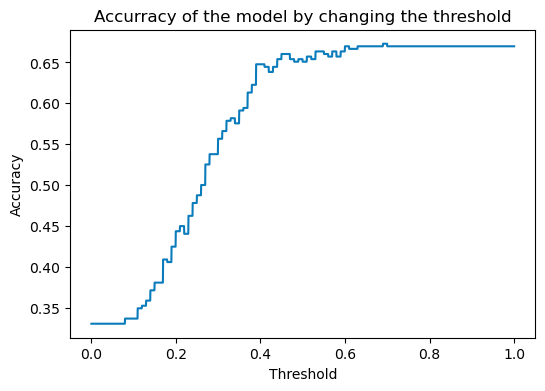

Pagados: 1066 Incobrables: 523
Accuracy mínimo: 67.0862177470107
Tamaño del data set:  1589
Porcentaje de impagados: 32.9138
------Best accurracy threshold Test scores for Random_Forest------
Recall: 0.9524
Precision: 100.0
F1-Score: 1.8868
Accuracy score: 67.2956
AUC Score: 50.4762
Accurracy Gain:  0.3121
Monetary Gain:  $-218,525
Reference Value:  $-224,409
Improvement:  2.6%
Model rejection rate 0.3%
False negative rate 32.8%


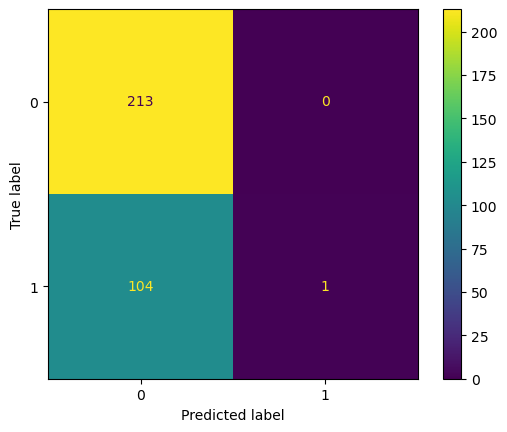

**************** Unbral para best monetary gain Test *******************
Best gain threshold =  0.39


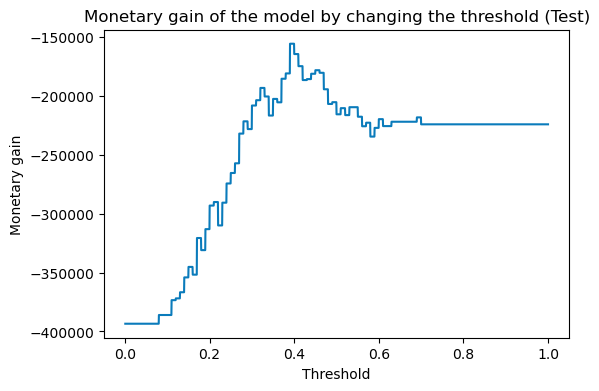

Model configuration:RNV_CC_CS
Pagados: 1066 Incobrables: 523
Accuracy mínimo: 67.0862177470107
Tamaño del data set:  1589
Porcentaje de impagados: 32.9138
------Best monetary gain threshold Test scores for Random_Forest------
Recall: 40.9524
Precision: 46.2366
F1-Score: 43.4343
Accuracy score: 64.7799
AUC Score: 58.7391
Accurracy Gain:  -3.4378
Monetary Gain:  $-156,097
Reference Value:  $-224,409
Improvement:  30.4%
Model rejection rate 29.2%
False negative rate 27.6%


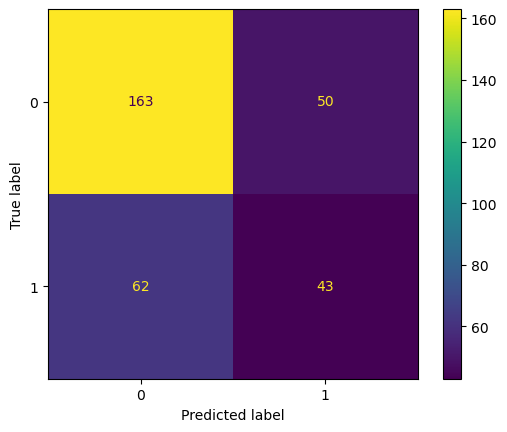

**************** Unbral para best monetary gain Train *******************
Best gain threshold =  0.31 with a monetary gain of 1575491.0


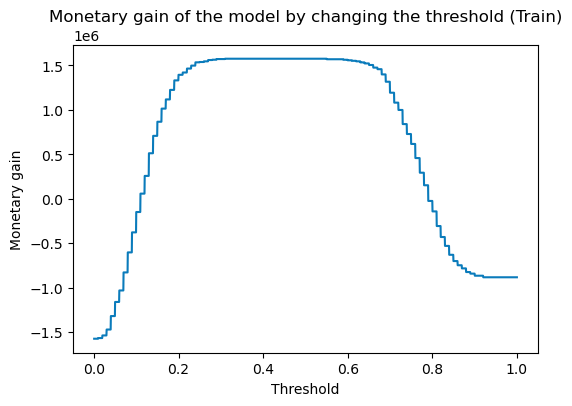

In [34]:
for model in models_tester.models:
    print(f"********************* Results for model: { model.name} : {model.parameters} *********************")
    print("********************** TEST **********************")
    y_pred_test = model.pipeline.predict(models_tester.x_test)
    all_stats.add_and_print_stats(models_tester.y_test, y_pred_test, model.name, model.parameters, "Test")

    print("********************** TRAIN **********************")
    y_pred_train = model.pipeline.predict(models_tester.x_train)
    all_stats.add_and_print_stats(models_tester.y_train, y_pred_train, model.name, model.parameters, "Train")
    
    #if (model.name != "Random Forest") and (model.name != "Ada Boost"):
    if (model.name != "Ada Boost"):
        ### Estadisticas con el mejor umbral para el accurracy y monetary gain

        predictions = model.pipeline.predict_proba(models_tester.x_test)[:,1]
        acceptance_threshold, accurracy_list, best_threshold, best_accurracy, gl, bgt, bg =  \
                                                                        pk.find_best_threshold(predictions, models_tester.y_test)
        model.best_gain_threshold = bgt
        model.best_accurracy_threshold = best_threshold
        
        print("**************** Unbral para best accurracy *******************")
        print("Best threshold = ", best_threshold)
        pk.plot_threshold_evolution(acceptance_threshold, accurracy_list, "Accurracy of the model by changing the threshold",
                                    "Threshold","Accuracy",
                                    f"{pkconfig.conf_column}_{model.name}_accuracy_test.png")
        y_pred_accuracy = np.where(predictions > best_threshold, 1, 0)
        all_stats.add_and_print_stats(models_tester.y_test, y_pred_accuracy, model.name, model.parameters, 
                                      "Best accurracy threshold Test", True,
                                      f"CM_{pkconfig.conf_column}_{model.name}_accuracy_test.png")

        ### Estadísticas de con la mejor ganancia monetária
        print("**************** Unbral para best monetary gain Test *******************")
        print("Best gain threshold = ", bgt)
        pk.plot_threshold_evolution(acceptance_threshold, gl, 
                                    "Monetary gain of the model by changing the threshold (Test)", 
                                    "Threshold", "Monetary gain",
                                    f"{pkconfig.conf_column}_{model.name}_best_gain_test.png")
        y_pred_monetary_test = np.where(predictions > bgt, 1, 0)
        print(f"Model configuration:{pkconfig.conf_column}")
        all_stats.add_and_print_stats(models_tester.y_test, y_pred_monetary_test, model.name, model.parameters, 
                                      "Best monetary gain threshold Test", True,
                                      f"CM_{pkconfig.conf_column}_{model.name}_monetary_test.png")

        ### Estadísticas con la mejor ganancia monetária datos de entrenamiento
        print("**************** Unbral para best monetary gain Train *******************")
        predictions = model.pipeline.predict_proba(models_tester.x_train)[:,1]
        acceptance_threshold, accurracy_list, best_threshold, best_accurracy, gl, bgt, bg = pk.find_best_threshold(predictions, models_tester.y_train)

        print("Best gain threshold = ", bgt, "with a monetary gain of", bg)
        pk.plot_threshold_evolution(acceptance_threshold, gl, "Monetary gain of the model by changing the threshold (Train)",
                                    "Threshold", "Monetary gain",
                                    f"{pkconfig.conf_column}_{model.name}_best_gain_train.png")

        y_pred_monetary_train = np.where(predictions > bgt, 1, 0)
        all_stats.add_and_print_stats(models_tester.y_train, y_pred_monetary_train, model.name, model.parameters,"Best monetary gain threshold Train")
    #model.min_max_stats = min_max_stats
    model.columns = models_tester.x_train.columns
    model.feature_engineering = pkconfig.feature_engineering
    model.features = all_features
    model.conf_column = pkconfig.conf_column
    model.data_parameters['zip_digits'] = pkconfig.zip_digits
    model.data_parameters['Training init date'] = train_init_date
    model.data_parameters['Trainig en date'] = train_end_date
    model.data_parameters['SourceFile'] = pkconfig.source_file_name
    model.data_parameters['Date'] = str_date_and_time
    if 'CP' in features_to_use:
        model.data_parameters['CP'] = training_cps
    if 'CP Aval' in features_to_use:
        model.data_parameters['CP Aval'] = training_cps_aval
    model.save_with_pickle()

In [35]:
for model in models_tester.models:
    print(model)
    print("=====================================")

Model name: Random_Forest
Feature engineering: standardization
Best gain threshold: 0.39



# Write statistics

## Write to data base

In [36]:
con = sqlite3.connect("promocash_stats.db")
cur = con.cursor()
cur.executemany("INSERT INTO stats VALUES(?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)", all_stats.values)
con.commit()

### Leer de la base de datos para escribir las estadísticas en la base de datos

In [37]:
df = pd.read_sql_query("SELECT * FROM stats", con)
df

,Date,TrainInitDate,TrainEndtDate,testInitDate,TestEndDate,Method,Evaluation,Size,Paid,Unpaid,...,ReferenceValue,Improvement,RejectionRate,ConfusionMatrix,False,Fetures,Parameters,Notes,SourceFile,Model
0,24/04/2024 17:36:30,Undefined,Undefined,Undefined,Undefined,Random_Forest_SMOTE,Test,28779,23368,5411,...,2266390.0,0.179125,0.125956,[[4271 403]\n [ 760 322]],0.151063,"{""Categorical"": [""CP"", ""Genero"", ""TipoZona"", ""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Valores Act Rech2NV_AgtProcessed.csv,NV_Agt
1,24/04/2024 17:36:30,Undefined,Undefined,Undefined,Undefined,Random_Forest_SMOTE,Train,28779,23368,5411,...,9055982.0,2.812708,0.188029,[[18694 0]\n [ 0 4329]],0.000000,"{""Categorical"": [""CP"", ""Genero"", ""TipoZona"", ""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Valores Act Rech2NV_AgtProcessed.csv,NV_Agt
2,24/04/2024 17:36:30,Undefined,Undefined,Undefined,Undefined,Random_Forest_SMOTE,Best accurracy threshold Test,28779,23368,5411,...,2266390.0,0.216101,0.028318,[[4625 49]\n [ 968 114]],0.173073,"{""Categorical"": [""CP"", ""Genero"", ""TipoZona"", ""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Valores Act Rech2NV_AgtProcessed.csv,NV_Agt
3,24/04/2024 17:36:30,Undefined,Undefined,Undefined,Undefined,Random_Forest_SMOTE,Best monetary gain threshold Test,28779,23368,5411,...,2266390.0,0.243064,0.066887,[[4495 179]\n [ 876 206]],0.163098,"{""Categorical"": [""CP"", ""Genero"", ""TipoZona"", ""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Valores Act Rech2NV_AgtProcessed.csv,NV_Agt
4,24/04/2024 17:36:30,Undefined,Undefined,Undefined,Undefined,Random_Forest_SMOTE,Best monetary gain threshold Train,28779,23368,5411,...,9055982.0,2.812708,0.188029,[[18694 0]\n [ 0 4329]],0.000000,"{""Categorical"": [""CP"", ""Genero"", ""TipoZona"", ""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Valores Act Rech2NV_AgtProcessed.csv,NV_Agt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,12/06/2026 18:21:26,Undefined,Undefined,Undefined,Undefined,Random_Forest,Test,1589,1066,523,...,-224409.0,0.037859,0.106918,[[193 20]\n [ 91 14]],0.320423,"{""Categorical"": [""Genero""], ""Quantitative"": [""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Data Set Cashia EntrenamientoRNV_CC_CSProcesse...,RNV_CC_CS
776,12/06/2026 18:21:26,Undefined,Undefined,Undefined,Undefined,Random_Forest,Train,1589,1066,523,...,-884021.0,2.782187,0.328875,[[853 0]\n [ 0 418]],0.000000,"{""Categorical"": [""Genero""], ""Quantitative"": [""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Data Set Cashia EntrenamientoRNV_CC_CSProcesse...,RNV_CC_CS
777,12/06/2026 18:21:26,Undefined,Undefined,Undefined,Undefined,Random_Forest,Best accurracy threshold Test,1589,1066,523,...,-224409.0,0.026220,0.003145,[[213 0]\n [104 1]],0.328076,"{""Categorical"": [""Genero""], ""Quantitative"": [""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Data Set Cashia EntrenamientoRNV_CC_CSProcesse...,RNV_CC_CS
778,12/06/2026 18:21:26,Undefined,Undefined,Undefined,Undefined,Random_Forest,Best monetary gain threshold Test,1589,1066,523,...,-224409.0,0.304408,0.292453,[[163 50]\n [ 62 43]],0.275556,"{""Categorical"": [""Genero""], ""Quantitative"": [""...","{""criterion"": ""gini"", ""bootstrap"": true, ""rand...",zip_digits = 4 Usando: standardizationSin rem...,Data Set Cashia EntrenamientoRNV_CC_CSProcesse...,RNV_CC_CS


In [38]:
time_now = datetime.now()

format_date_hour = "%Y-%m-%d %H:%M:%S"
date_and_hour = time_now.strftime(format_date_hour)

# Imprimir la fecha y hora
print("Ended at:", date_and_hour)

Ended at: 2026-06-12 18:22:05


In [39]:
con.commit()
con.close()

In [40]:
df.index.name = 'index'
df.to_excel("./statistics/"+pkconfig.stats_file_name)

In [41]:
# Escribir el archivo de data tracking
data_tracker.to_dataframe().to_csv("./data/" + pkconfig.conf_column + "_data_tracking_train.csv")

In [42]:
test_result = models_tester.x_test.copy()
test_result["Prediction"] = y_pred_monetary_test
test_result["Incobrable"] = models_tester.y_test
test_result

,Monto,Edad Solicitud,Genero,Dependientes,Ingresos,Egresos,Score CC,Ciclo,Monto_Ant,Frecuencia_Ant,Score_Ant,Deficit,IngresoPercapita,Odds,Mes inicial,Prediction,Incobrable
id_solicitud,,,,,,,,,,,,,,,,,
111734,7000,34,Femenino,2,15499,4428,647,4,6642,0.945580,0.20454,10000,5166,6.1,11,0,0
136833,4000,40,Masculino,2,7054,2713,526,3,3255,1.134703,0.93576,4000,2351,2.2,5,1,0
130861,6000,54,Femenino,0,8233,4874,648,2,3249,1.288988,1.02126,3100,8233,6.1,4,0,0
136850,4500,62,Femenino,0,6511,7488,477,6,4341,0.945584,0.58308,-900,6511,1.6,5,0,0
141659,3500,22,Femenino,0,5189,1081,653,6,3243,1.190783,1.00644,3800,5189,6.1,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131819,6000,54,Femenino,0,8124,3791,575,2,3249,1.134703,1.02356,4000,8124,3.5,4,0,0
133113,8000,54,Masculino,1,13541,10833,425,2,4874,0.773661,0.40150,2500,6770,1.2,4,0,0
136534,14500,30,Femenino,1,14651,2170,608,2,8682,1.701911,0.94062,11500,7325,4.6,5,0,1


In [43]:
test_result.to_csv("./data/TestResult"+pkconfig.conf_column+".csv")

In [44]:
preprocessor.fit(models_tester.x_train)
x_test_processed = preprocessor.transform(models_tester.x_test)

# Crear DataFrame a partir de los datos transformados
x_test_transformed_df = pd.DataFrame(
    data=x_test_processed,
    columns=models_tester.x_test.columns
)

In [45]:
models_tester.x_test.columns

Index(['Monto', 'Edad Solicitud', 'Genero', 'Dependientes', 'Ingresos',
       'Egresos', 'Score CC', 'Ciclo', 'Monto_Ant', 'Frecuencia_Ant',
       'Score_Ant', 'Deficit', 'IngresoPercapita', 'Odds', 'Mes inicial'],
      dtype='object')

In [46]:
x_test_processed[0]

array([ 0.        , -0.6616435 , -0.2934762 ,  0.695439  , -0.23283701,
        1.90461358, -0.50527705,  0.19622421,  0.04520536, -0.46031525,
       -1.04053675,  0.57110325,  1.77988526,  1.42009177,  1.12050697])

In [47]:
x_test_transformed_df["Prediccion"] = models_tester.y_test.to_numpy()

In [48]:
models_tester.y_test

id_solicitud
111734    0
136833    0
130861    0
136850    0
141659    0
         ..
131819    0
133113    0
136534    1
133806    0
140418    0
Name: Incobrable, Length: 318, dtype: int64

In [49]:
x_test_transformed_df

,Monto,Edad Solicitud,Genero,Dependientes,Ingresos,Egresos,Score CC,Ciclo,Monto_Ant,Frecuencia_Ant,Score_Ant,Deficit,IngresoPercapita,Odds,Mes inicial,Prediccion
0,0.0,-0.661643,-0.293476,0.695439,-0.232837,1.904614,-0.505277,0.196224,0.045205,-0.460315,-1.040537,0.571103,1.779885,1.420092,1.120507,0
1,1.0,-0.147347,-0.792931,-0.363625,-1.021999,-0.223842,-1.036025,-0.299603,-0.926942,0.018654,0.771772,-0.824499,-0.266911,0.174108,1.120507,0
2,0.0,0.272212,-0.163589,-0.522485,-0.495891,-0.578585,0.072984,-0.795430,-0.928664,1.136248,0.983681,-0.629660,1.779885,1.430389,-0.960084,0
3,0.0,-0.661633,0.597680,-1.228528,-0.890472,-0.223842,-0.251687,1.187878,-0.615235,1.774874,-0.102336,-0.914234,-0.581802,-0.330464,-0.960084,0
4,0.0,0.005156,-1.268215,-0.398927,-1.153526,0.130900,-0.500941,1.187878,-0.930386,-1.418253,0.946950,-1.132705,1.779885,1.481876,-0.960084,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,0.0,-0.147347,-0.478988,-0.363625,-0.495891,-0.578585,0.052432,-0.795430,-0.928664,1.136248,0.989382,-0.647673,0.415355,0.678680,-0.960084,0
314,1.0,-1.129155,1.571836,-0.628391,0.030217,-0.578585,-0.202854,-0.795430,-0.462252,1.136248,-0.552377,0.247528,-0.791730,-0.865929,0.080212,0
315,0.0,1.395103,-0.951068,0.960205,1.740069,-0.223842,-0.098213,-0.795430,0.630733,-0.779628,0.783817,0.430965,0.992656,1.018494,0.080212,1
316,1.0,0.015633,-0.478988,-0.275370,0.293271,-0.578585,-0.662333,-0.299603,-0.151118,-1.577910,0.956319,-0.558103,-0.791730,-0.938010,0.080212,0


In [50]:
time_now = datetime.now()

date_and_hour = time_now.strftime(format_date_hour)

# Imprimir la fecha y hora
print("Ended at:", date_and_hour)

Ended at: 2026-06-12 18:22:06


In [51]:
# Hacer un sonido
if sys.platform.startswith("win"):
    import winsound
    winsound.Beep(1000, 500)  # Frecuencia de 1000 Hz, duración de 500 ms
    winsound.Beep(500, 500) 
    winsound.Beep(1000, 500) 
else:
    print('\a')  # Hace un beep en algunos sistemas UNIX
    
print('Configuration : ', pkconfig.conf_column)

Configuration :  RNV_CC_CS


In [52]:
len(x_test_transformed_df)

318

In [53]:
models_tester.y_test

id_solicitud
111734    0
136833    0
130861    0
136850    0
141659    0
         ..
131819    0
133113    0
136534    1
133806    0
140418    0
Name: Incobrable, Length: 318, dtype: int64

In [54]:

max_score_value = data['Score Agt'].max()
min_score_value = data['Score Agt'].min()
print("Min: ", min_score_value)
print("Max: ", max_score_value)

KeyError: 'Score Agt'

In [ ]:
n_groups = 100
bins = np.linspace(min_score_value, max_score_value, n_groups+1)
labels = list(range(1,n_groups+1))

In [ ]:
bins

In [ ]:
# x_test_transformed_df['Group'] = pd.cut(models_tester.x_test['Score Agt'], bins, labels=labels)

groups = pd.cut(
    models_tester.x_test['Score Agt'].to_numpy(),  # sin índice
    bins=bins,
    labels=labels
)

x_test_transformed_df['Group'] = groups  # groups ya no tiene índice de pandas


In [ ]:
intervals = [f"[{bins[i]:.3f}, {bins[i+1]:.3f}]" for i in range(0, n_groups)]

In [ ]:
x_test_transformed_df

In [ ]:
grouped_data_mean = x_test_transformed_df.groupby('Group').mean()
grouped_data_mean = grouped_data_mean.reset_index()

In [ ]:
grouped_data_mean = grouped_data_mean.rename(columns={"Prediccion":'% Predicción de incobrables'})

In [ ]:
grouped_data_mean.columns

In [ ]:
grouped_data_mean.plot.bar(x='Group', y='% Predicción de incobrables',  ylabel="% Predicción de incobrables",)

In [ ]:
grouped_data_mean[['Group', '% Predicción de incobrables']]

In [ ]:
grouped_data_count = x_test_transformed_df.groupby('Group').count()
grouped_data_count = grouped_data_count.reset_index()
grouped_data_count = grouped_data_count.rename(columns={'Prediccion':'No. de Créditos'})

In [ ]:
grouped_data_count

In [ ]:
grouped_data_count[['Group','No. de Créditos']]

In [ ]:
grouped_data_count.plot.bar(x='Group', y='No. de Créditos',  ylabel="No créditos",)

In [ ]:
grouped_data_sum = x_test_transformed_df.groupby('Group').sum()
grouped_data_sum = grouped_data_sum.reset_index()
grouped_data_sum = grouped_data_sum.rename(columns={'Prediccion':'No. Créditos rechazados'})

In [ ]:
grouped_data_sum[['Group','No. Créditos rechazados']]

In [ ]:
grouped_data_sum['No. Créditos'] = grouped_data_count['No. de Créditos']

In [ ]:
grouped_data_sum[['No. Créditos', 'No. Créditos rechazados']]

In [ ]:
grouped_data_sum['No Créditos aprobados'] = grouped_data_sum['No. Créditos'] - grouped_data_sum['No. Créditos rechazados']

In [ ]:
grouped_data_sum[['Group','No. Créditos', 'No. Créditos rechazados', 'No Créditos aprobados']]

In [ ]:
grouped_data_sum[['Group', 'No. Créditos rechazados', 'No Créditos aprobados']].plot.bar(x='Group', stacked=True, rot=0);

In [ ]:
zoom_data = grouped_data_sum[(grouped_data_sum['Group']>=40) & (grouped_data_sum['Group']<=60)]

In [ ]:
zoom_data[['Group','No. Créditos', 'No. Créditos rechazados', 'No Créditos aprobados']]

In [ ]:
zoom_data[['Group', 'No. Créditos rechazados', 'No Créditos aprobados']].plot.bar(x='Group', stacked=True, rot=0)

In [ ]:
#training_cps.to_excel("training_cps.xlsx")

In [ ]:
data.head()

In [ ]:
list(data.columns).sort()

In [ ]:
data.shape[0]